In [1]:
import os
import matplotlib.pyplot as plt
import random
import numpy as np
import rasterio
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
import torch
from torchinfo import summary

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
!pip install -q torchinfo

In [3]:
!pip install rasterio

In [4]:
!pip install -q segmentation-models-pytorch

In [5]:
base_dir = '/kaggle/input/datasets/maryamalajarmeh/water-dataset/water_dataset'

images_dir = os.path.join(base_dir, 'images')
labels_dir   = os.path.join(base_dir, 'labels')

In [6]:
image_files = sorted(os.listdir(images_dir))
label_files = sorted(os.listdir(labels_dir))

print("Number of images:", len(image_files))
print("Number of labels:", len(label_files))

Number of images: 306
Number of labels: 456


In [7]:
print("First 10 image files:")
print(image_files[:10])

print("\nFirst 10 label files:")
print(label_files[:10])

First 10 image files:
['0.tif', '1.tif', '10.tif', '100.tif', '101.tif', '102.tif', '103.tif', '104.tif', '105.tif', '106.tif']

First 10 label files:
['0.png', '1.png', '10.png', '100.png', '100_184.png', '101.png', '101_89.png', '102.png', '102_179.png', '103.png']


In [8]:
clean_label_files = [f for f in label_files if "_" not in f]

print("Clean labels count:", len(clean_label_files))

Clean labels count: 306


In [9]:
image_files = sorted(image_files)
label_files = sorted(clean_label_files)

print("Images:", len(image_files))
print("Labels:", len(label_files))

Images: 306
Labels: 306


In [10]:
sample_image_path = os.path.join(images_dir, image_files[0])

with rasterio.open(sample_image_path) as src:
    image = src.read()

print("Raw shape (bands, H, W):", image.shape)

Raw shape (bands, H, W): (12, 128, 128)


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [11]:
image = np.transpose(image, (1, 2, 0))

print("Transposed shape (H, W, bands):", image.shape)
print("Data type:", image.dtype)
print("Min value:", image.min())
print("Max value:", image.max())

Transposed shape (H, W, bands): (128, 128, 12)
Data type: int16
Min value: -28
Max value: 4975


In [12]:
sample_label_path = os.path.join(labels_dir, label_files[0])

mask = plt.imread(sample_label_path)
mask = (mask > 0).astype(np.float32)

print("Mask shape:", mask.shape)
print("Unique mask values:", np.unique(mask))

Mask shape: (128, 128)
Unique mask values: [0. 1.]


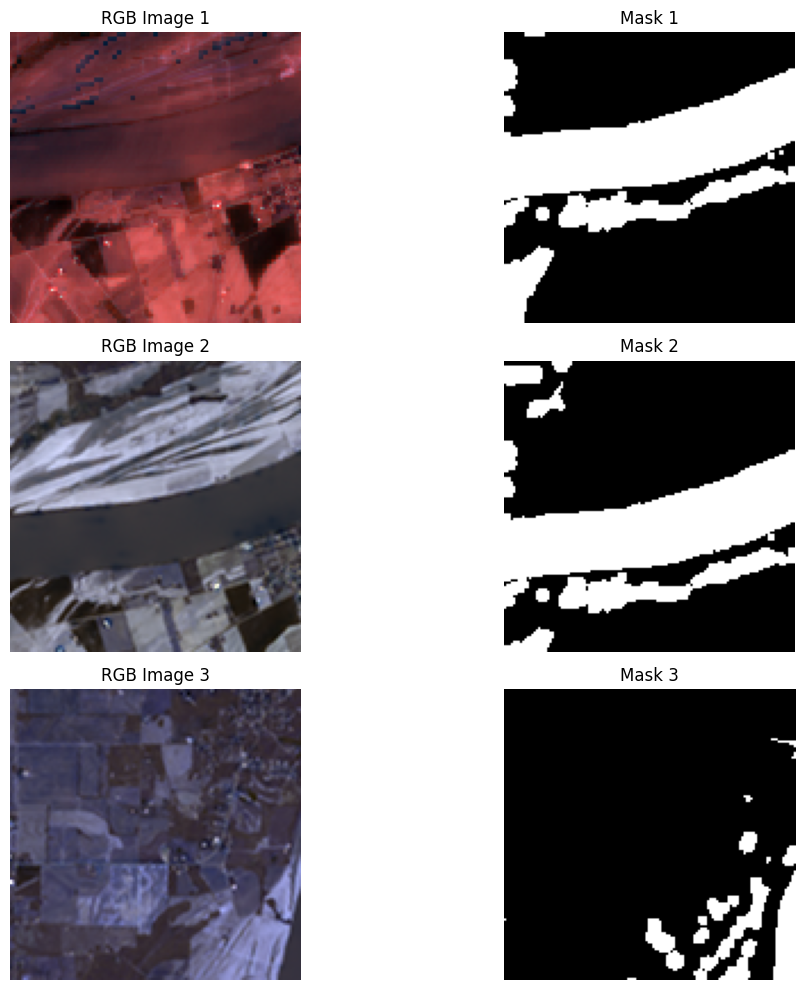

In [13]:
def load_image(path):
    with rasterio.open(path) as src:
        img = src.read()  # (bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # (H, W, bands)
    return img

def load_mask(path):
    mask = plt.imread(path)
    mask = (mask > 0).astype(np.float32)
    return mask

def normalize_rgb(image):
    rgb = image[:, :, :3].astype(np.float32)

    for i in range(3):
        band = rgb[:, :, i]
        rgb[:, :, i] = (band - band.min()) / (band.max() - band.min() + 1e-8)

    return rgb

indices = random.sample(range(len(image_files)), 3)

plt.figure(figsize=(12, 10))

for i, idx in enumerate(indices):
    img_path = os.path.join(images_dir, image_files[idx])
    mask_path = os.path.join(labels_dir, label_files[idx])

    image = load_image(img_path)
    mask = load_mask(mask_path)
    rgb_display = normalize_rgb(image)

    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(rgb_display)
    plt.title(f"RGB Image {i+1}")
    plt.axis("off")


    plt.subplot(3, 2, 2*i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
images = []
masks = []

for img_file, mask_file in zip(image_files, label_files):
    img_path = os.path.join(images_dir, img_file)
    mask_path = os.path.join(labels_dir, mask_file)

    images.append(load_image(img_path))
    masks.append(load_mask(mask_path))

X = np.array(images)
y = np.array(masks)
y = np.expand_dims(y, axis=-1)
print("X shape:", X.shape)   # (N, 128,128,12)
print("y shape:", y.shape)   # (N,128,128,1)

X shape: (306, 128, 128, 12)
y shape: (306, 128, 128, 1)


In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (244, 128, 128, 12)
Validation: (62, 128, 128, 12)


In [16]:
X_train = X_train.astype(np.float32)

global_min = np.min(X_train, axis=(0,1,2))  # shape (12,)
global_max = np.max(X_train, axis=(0,1,2))

print(global_min)
print(global_max)

[-1.393e+03 -1.169e+03 -7.220e+02 -6.840e+02 -4.120e+02 -3.350e+02
 -2.510e+02  6.400e+01 -9.999e+03  8.000e+00  1.000e+01  0.000e+00]
[ 6568.  9659. 11368. 12041. 15841. 15252. 14647.   255.  4245.  4287.
   100.   111.]


In [17]:
def normalize_global(X, gmin, gmax):
    return (X - gmin) / (gmax - gmin + 1e-8)

X_train = normalize_global(X_train, global_min, global_max)
X_val   = normalize_global(X_val, global_min, global_max)

In [18]:
import segmentation_models_pytorch as smp
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",   # Transfer Learning 
    in_channels=12,               # 12 bands
    classes=1                     # binary segmentation
)

model = model.to(DEVICE)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [19]:
summary(model, input_size=(1, 12, 128, 128))

Layer (type:depth-idx)                                  Output Shape              Param #
Unet                                                    [1, 1, 128, 128]          --
├─EfficientNetEncoder: 1-1                              [1, 12, 128, 128]         412,160
│    └─Conv2dStaticSamePadding: 2-1                     [1, 32, 64, 64]           3,456
│    │    └─ZeroPad2d: 3-1                              [1, 12, 129, 129]         --
│    └─BatchNorm2d: 2-2                                 [1, 32, 64, 64]           64
│    └─SiLU: 2-3                                        [1, 32, 64, 64]           --
│    └─ModuleList: 2-4                                  --                        --
│    │    └─MBConvBlock: 3-2                            [1, 16, 64, 64]           1,448
│    │    └─MBConvBlock: 3-3                            [1, 24, 32, 32]           6,004
│    │    └─MBConvBlock: 3-4                            [1, 24, 32, 32]           10,710
│    │    └─MBConvBlock: 3-5              

In [20]:
dice_loss = smp.losses.DiceLoss(mode="binary")

In [21]:
bce_loss = smp.losses.SoftBCEWithLogitsLoss()

def combined_loss(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

In [22]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [23]:
def dice_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    dice = (2. * intersection + 1e-7) / (union + 1e-7)
    return dice

In [24]:
def iou_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-7) / (union + 1e-7)
    return iou

In [25]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)  # (B,12,128,128)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)


y_train_tensor = torch.tensor(y_train, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)  # (B,1,128,128)
y_val_tensor   = torch.tensor(y_val, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)

print("X_train_tensor:", X_train_tensor.shape)  # (244,12,128,128)
print("y_train_tensor:", y_train_tensor.shape)  # (244,1,128,128)
print("X_val_tensor:", X_val_tensor.shape)      # (62,12,128,128)
print("y_val_tensor:", y_val_tensor.shape)      # (62,1,128,128)

X_train_tensor: torch.Size([244, 12, 128, 128])
y_train_tensor: torch.Size([244, 1, 128, 128])
X_val_tensor: torch.Size([62, 12, 128, 128])
y_val_tensor: torch.Size([62, 1, 128, 128])


In [26]:
EPOCHS = 20
BATCH_SIZE = 8

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_dice = 0
    train_iou  = 0

    # Training
    for i in range(0, X_train_tensor.shape[0], BATCH_SIZE):
        images = X_train_tensor[i:i+BATCH_SIZE]
        masks  = y_train_tensor[i:i+BATCH_SIZE]

        optimizer.zero_grad()
        outputs = model(images)

        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(outputs, masks).item()
        train_iou  += iou_score(outputs, masks).item()

    # Validation
    model.eval()
    val_loss = 0
    val_dice = 0
    val_iou  = 0
    with torch.no_grad():
        for i in range(0, X_val_tensor.shape[0], BATCH_SIZE):
            images = X_val_tensor[i:i+BATCH_SIZE]
            masks  = y_val_tensor[i:i+BATCH_SIZE]

            outputs = model(images)
            loss = combined_loss(outputs, masks)

            val_loss += loss.item()
            val_dice += dice_score(outputs, masks).item()
            val_iou  += iou_score(outputs, masks).item()

    # Print
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss/(X_train_tensor.shape[0]/BATCH_SIZE):.4f} | "
          f"Train Dice: {train_dice/(X_train_tensor.shape[0]/BATCH_SIZE):.4f} | "
          f"Train IoU: {train_iou/(X_train_tensor.shape[0]/BATCH_SIZE):.4f}")
    print(f"Val   Loss: {val_loss/(X_val_tensor.shape[0]/BATCH_SIZE):.4f} | "
          f"Val   Dice: {val_dice/(X_val_tensor.shape[0]/BATCH_SIZE):.4f} | "
          f"Val   IoU: {val_iou/(X_val_tensor.shape[0]/BATCH_SIZE):.4f}")


Epoch [1/20]
Train Loss: 1.3121 | Train Dice: 0.4613 | Train IoU: 0.3073
Val   Loss: 1.3431 | Val   Dice: 0.4706 | Val   IoU: 0.3090

Epoch [2/20]
Train Loss: 1.0844 | Train Dice: 0.5881 | Train IoU: 0.4248
Val   Loss: 1.1770 | Val   Dice: 0.5655 | Val   IoU: 0.3987

Epoch [3/20]
Train Loss: 0.9321 | Train Dice: 0.7007 | Train IoU: 0.5474
Val   Loss: 1.0785 | Val   Dice: 0.5197 | Val   IoU: 0.3602

Epoch [4/20]
Train Loss: 0.8104 | Train Dice: 0.7713 | Train IoU: 0.6349
Val   Loss: 0.9951 | Val   Dice: 0.5807 | Val   IoU: 0.4155

Epoch [5/20]
Train Loss: 0.7234 | Train Dice: 0.8034 | Train IoU: 0.6768
Val   Loss: 0.9638 | Val   Dice: 0.6057 | Val   IoU: 0.4366

Epoch [6/20]
Train Loss: 0.6469 | Train Dice: 0.8330 | Train IoU: 0.7160
Val   Loss: 0.9485 | Val   Dice: 0.5923 | Val   IoU: 0.4274

Epoch [7/20]
Train Loss: 0.5955 | Train Dice: 0.8457 | Train IoU: 0.7347
Val   Loss: 0.8385 | Val   Dice: 0.6921 | Val   IoU: 0.5300

Epoch [8/20]
Train Loss: 0.5511 | Train Dice: 0.8578 | Train 

In [27]:
BATCH_SIZE = 8

val_losses = []
val_dices = []
val_ious = []

model.eval()
with torch.no_grad():
    for i in range(0, X_val_tensor.shape[0], BATCH_SIZE):
        images = X_val_tensor[i:i+BATCH_SIZE]
        masks  = y_val_tensor[i:i+BATCH_SIZE]

        outputs = model(images)
        loss = combined_loss(outputs, masks)

        dice = dice_score(outputs, masks).item()
        iou  = iou_score(outputs, masks).item()

        val_losses.append(loss.item())
        val_dices.append(dice)
        val_ious.append(iou)

        print(f"{i//BATCH_SIZE + 1}/{(X_val_tensor.shape[0]+BATCH_SIZE-1)//BATCH_SIZE} "
              f"━ step ━ loss: {loss.item():.4f} - f1_score: {dice:.4e} - iou_metric: {iou:.4e}")

final_metrics = [sum(val_losses)/len(val_losses),
                 sum(val_dices)/len(val_dices),
                 sum(val_ious)/len(val_ious)]

print(final_metrics)

1/8 ━ step ━ loss: 0.4116 - f1_score: 8.3247e-01 - iou_metric: 7.1302e-01
2/8 ━ step ━ loss: 0.4211 - f1_score: 8.0746e-01 - iou_metric: 6.7709e-01
3/8 ━ step ━ loss: 0.3360 - f1_score: 8.6939e-01 - iou_metric: 7.6895e-01
4/8 ━ step ━ loss: 0.3286 - f1_score: 8.7488e-01 - iou_metric: 7.7759e-01
5/8 ━ step ━ loss: 0.3547 - f1_score: 8.6892e-01 - iou_metric: 7.6822e-01
6/8 ━ step ━ loss: 0.2407 - f1_score: 9.2377e-01 - iou_metric: 8.5834e-01
7/8 ━ step ━ loss: 0.7849 - f1_score: 6.5079e-01 - iou_metric: 4.8235e-01
8/8 ━ step ━ loss: 0.3556 - f1_score: 8.9837e-01 - iou_metric: 8.1549e-01
[0.4041493162512779, 0.8407560586929321, 0.7326316237449646]


In [32]:
def visualize_random_predictions(model, X_val_tensor, y_val_tensor, DEVICE, num_images=3, threshold=0.5):
    """
    Displays num_images random validation images with ground truth and predictions
    """
    model.eval()
    indices = random.sample(range(X_val_tensor.shape[0]), num_images)  # random indices

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4*num_images))

    with torch.no_grad():
        for row, idx in enumerate(indices):
            image = X_val_tensor[idx].unsqueeze(0).to(DEVICE)
            mask  = y_val_tensor[idx].to(DEVICE)

            # Prediction
            pred = torch.sigmoid(model(image))
            pred = (pred > threshold).float()

            # Convert to numpy
            img_np  = image[0].cpu().numpy()       # (12,128,128)
            mask_np = mask.squeeze(0).cpu().numpy()  # (128,128)
            pred_np = pred[0,0].cpu().numpy()        # (128,128)

            # RGB view (first 3 bands)
            rgb = img_np[:3].transpose(1,2,0)
            rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

            # Plot Input RGB
            axes[row,0].imshow(rgb)
            axes[row,0].set_title(f"Image {idx} - RGB")
            axes[row,0].axis("off")

            # Plot Ground Truth Mask
            axes[row,1].imshow(mask_np, cmap="gray")
            axes[row,1].set_title(f"Image {idx} - Ground Truth")
            axes[row,1].axis("off")

            # Plot Predicted Mask
            axes[row,2].imshow(pred_np, cmap="gray")
            axes[row,2].set_title(f"Image {idx} - Prediction")
            axes[row,2].axis("off")
    
    plt.tight_layout()
    plt.show()

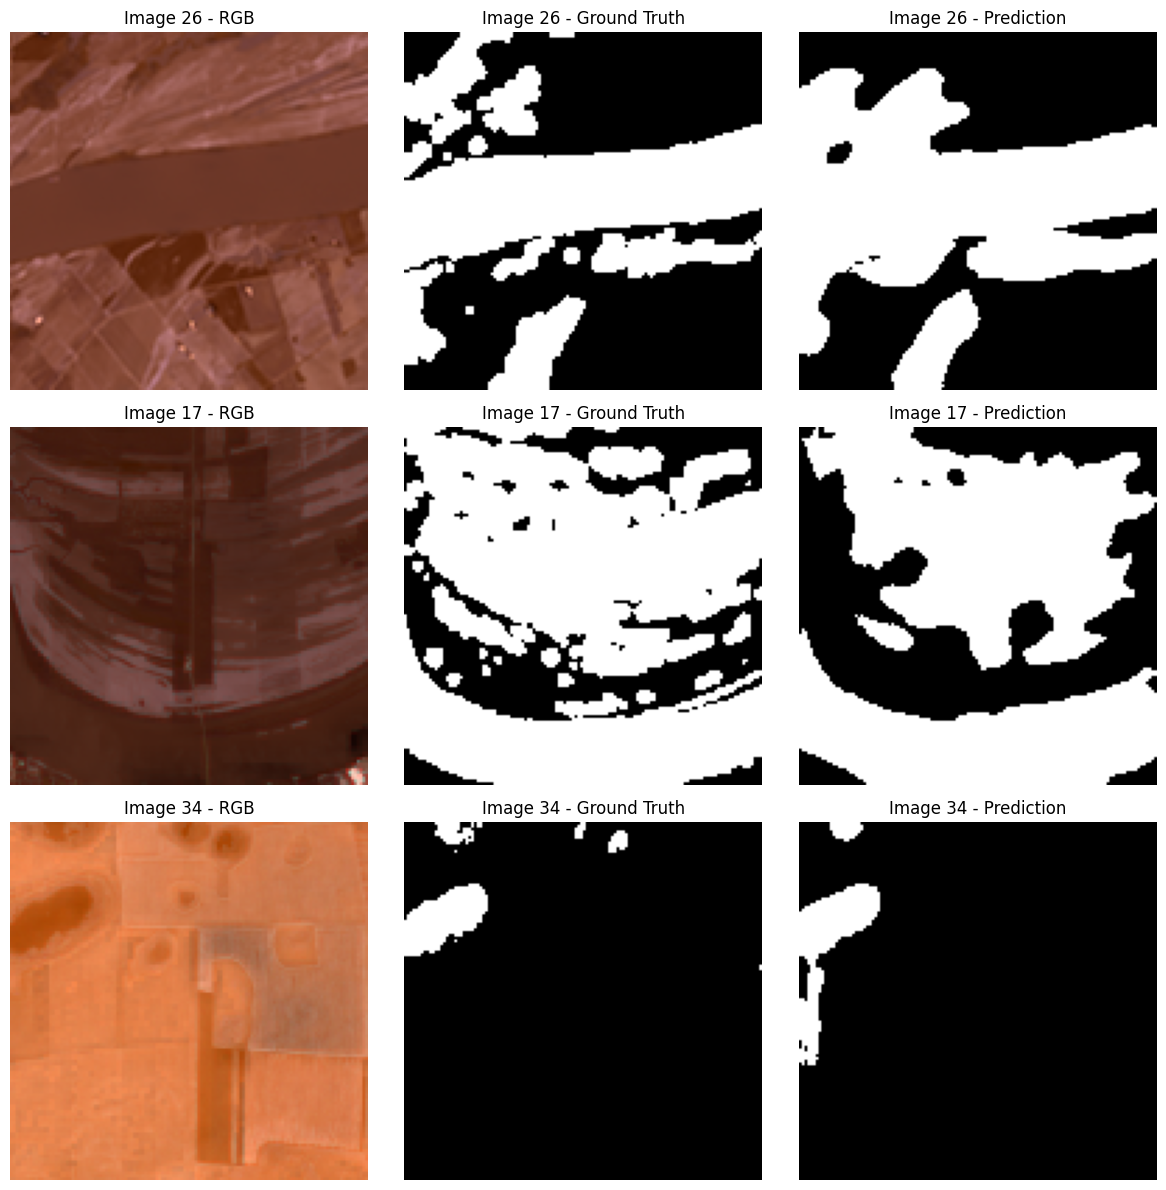

In [34]:
visualize_random_predictions(model, X_val_tensor, y_val_tensor, DEVICE)